In [68]:
import numpy as np
from scipy.stats import truncnorm
from scipy.integrate import quad
import pandas as pd
import matplotlib.pyplot as plt

def truncated_gaussian_pdf(y, mu=0.3, sigma=0.3, a=0, b=1):
    """
    Truncated Gaussian PDF evaluated at y with support [a, b], mean mu and std deviation sigma.
    """
    trunc_gauss = truncnorm((a - mu) / sigma, (b - mu) / sigma, loc=mu, scale=sigma)
    return trunc_gauss.pdf(y)

def piecewise_uniform_pdf(y, tau_l, tau_h, beta_1=0.01, beta_2=0.95):
    if 0 <= y < tau_l:
        return beta_1 / tau_l
    elif tau_l <= y < tau_h:
        return beta_2 / (tau_h - tau_l)
    elif tau_h <= y <= 1:
        return (1 - (beta_1 + beta_2)) / (1 - tau_h)
    else:
        return 0.0

def utility_function(gamma, tau_l, tau_h, dist_type='piecewise_uniform'):
   
    if dist_type == 'trunc_gauss':
        integrand = lambda y: ((2 + gamma) * y - 1) * truncated_gaussian_pdf(y)
    elif dist_type == 'piecewise_uniform':
        integrand = lambda y: ((2 + gamma) * y - 1) * piecewise_uniform_pdf(y, tau_l, tau_h)
    else:
        raise ValueError(f"Unknown distribution type: {dist_type}")

    result, _ = quad(integrand, tau_l, tau_h)
    return result

def get_utility_matrix(gamma_l, gamma_h, tau_l, tau_h):
    U1 = np.array([[utility_function(gamma_l, tau_l, 1)/2, 0, utility_function(gamma_l, tau_h, 1)/2, 0],
     [utility_function(gamma_l, tau_l, 1), utility_function(gamma_h, tau_l, 1)/2, utility_function(gamma_l, tau_h, 1), utility_function(gamma_h, tau_h, 1)/2],
     [utility_function(gamma_l, tau_l, tau_h) + utility_function(gamma_l, tau_h, 1)/2, utility_function(gamma_h, tau_l, tau_h), utility_function(gamma_l, tau_h, 1)/2, 0],
     [utility_function(gamma_l, tau_l, 1), utility_function(gamma_h, tau_l, tau_h) + utility_function(gamma_h, tau_h, 1)/2, utility_function(gamma_l, tau_h, 1), utility_function(gamma_h, tau_h, 1)/2]
    ])
    return U1
    
gamma_l = 0.6
gamma_h = 0.7
tau_l = 1 / (2 + gamma_h)
tau_h = 1 / (2 + gamma_l)
sample_type = 'piecewise_uniform'

In [70]:
import numpy as np
from scipy.stats import truncnorm

def utility_function_sample(gamma, tau_l, tau_h, t, n_s, dist_type='piecewise_uniform'):
    """
    Monte Carlo estimate of the utility:
    E[((2 + gamma)y - 1) | y ∈ [tau_l, tau_h]] from samples of specified distribution.
    
    Parameters:
        gamma: scalar
        tau_l: lower integration bound (same as tau_a)
        tau_h: upper integration bound (same as tau_b)
        t: seed for reproducibility
        n_s: number of samples
        dist_type: 'trunc_gauss' or 'piecewise_uniform'
    """
    if dist_type == 'trunc_gauss':
        # Truncated normal sampler
        mu, sigma = 0.3, 0.1
        a, b = 0, 1
        trunc_gauss = truncnorm((a - mu) / sigma, (b - mu) / sigma, loc=mu, scale=sigma)
        samples = trunc_gauss.rvs(n_s, random_state=t)
    
    elif dist_type == 'piecewise_uniform':
        # Piecewise uniform sampling
        beta_1, beta_2 = 0.01, 0.95
        weights = [beta_1, beta_2, 1 - beta_1 - beta_2]
        ranges = [
            (0, tau_l),
            (tau_l, tau_h),
            (tau_h, 1)
        ]
        # Choose region indices
        region_choices = np.random.choice([0, 1, 2], size=n_s, p=weights)
        samples = np.zeros(n_s)
        rng = np.random.default_rng(seed=t)
        for i, region in enumerate(region_choices):
            low, high = ranges[region]
            samples[i] = rng.uniform(low, high)
    
    else:
        raise ValueError(f"Unknown distribution type: {dist_type}")
    
    # Filter samples in [tau_l, tau_h]
    filtered_samples = samples[(samples >= tau_l) & (samples <= tau_h)]
    
    if len(filtered_samples) == 0:
        return 0.0  # or np.nan
    
    utility_values = ((2 + gamma) * filtered_samples - 1)
    return np.mean(utility_values)

def get_utility_matrix_sample(gamma_l, gamma_h, tau_l, tau_h, t, n_s):
    U1 = np.array([
        [
            utility_function_sample(gamma_l, tau_l, 1, t, n_s) / 2,
            0,
            utility_function_sample(gamma_l, tau_h, 1, t, n_s) / 2,
            0
        ],
        [
            utility_function_sample(gamma_l, tau_l, 1, t, n_s),
            utility_function_sample(gamma_h, tau_l, 1, t, n_s) / 2,
            utility_function_sample(gamma_l, tau_h, 1, t, n_s),
            utility_function_sample(gamma_h, tau_h, 1, t, n_s) / 2
        ],
        [
            utility_function_sample(gamma_l, tau_l, tau_h, t, n_s) + utility_function_sample(gamma_l, tau_h, 1, t, n_s) / 2,
            utility_function_sample(gamma_h, tau_l, tau_h, t, n_s),
            utility_function_sample(gamma_l, tau_h, 1, t, n_s) / 2,
            0
        ],
        [
            utility_function_sample(gamma_l, tau_l, 1, t, n_s),
            utility_function_sample(gamma_h, tau_l, tau_h, t, n_s) + utility_function_sample(gamma_h, tau_h, 1, t, n_s) / 2,
            utility_function_sample(gamma_l, tau_h, 1, t, n_s),
            utility_function_sample(gamma_h, tau_h, 1, t, n_s) / 2
        ]
    ])
    
    return U1


In [75]:
#sanity check
print(utility_function_sample(0.4,0.1,0.7,1,1000))
print(utility_function(0.4,0.1,0.7))
print(get_utility_matrix_sample(gamma_l, gamma_h, tau_l, tau_h, 2, 1))

-0.03755572058515052
-0.03800000000000011
[[0.19561586 0.         0.20928971 0.        ]
 [0.39123172 0.22237031 0.41857941 0.23657008]
 [0.20928971 0.01006201 0.20928971 0.        ]
 [0.39123172 0.24663209 0.41857941 0.23657008]]


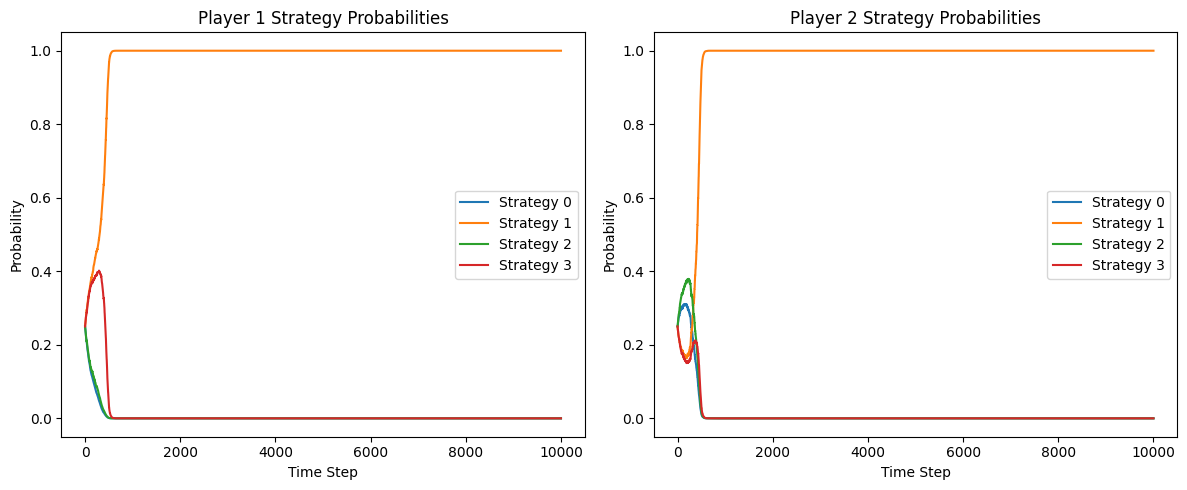

In [73]:
def exponential_weights(T, eta, num_actions, gamma_l, gamma_h, tau_l, tau_h, n_s):

    p1 = np.ones((T+1, num_actions)) / num_actions
    p2 = np.ones((T+1, num_actions)) / num_actions
    
      # Assume zero-sum game for illustration
    
    # Simulate algorithm
    for t in range(T):
        U1 = get_utility_matrix_sample(gamma_l, gamma_h, tau_l, tau_h, t, n_s)
        U2 = U1.T

        # Sample strategy
        s1 = np.random.choice(num_actions, p=p1[t])
        s2 = np.random.choice(num_actions, p=p2[t])
    
        # Compute utilities using sampled strategy of the current player
        util1 = np.array([p2[t, j]*U1[j, s1] for j in range(num_actions)])
        util2 = np.array([p1[t, j]*U2[j, s2] for j in range(num_actions)])
    
        # Update probabilities using exponential weights
        p1[t+1] = p1[t] * np.exp(eta * util1)
        p2[t+1] = p2[t] * np.exp(eta * util2)
    
        # Normalize
        p1[t+1] /= np.sum(p1[t+1])
        p2[t+1] /= np.sum(p2[t+1])
    return p1, p2

def plot_probabilities_per_player(p1, p2):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    for i in range(4):
        plt.plot(p1[:, i], label=f'Strategy {i}')
    plt.title('Player 1 Strategy Probabilities')
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    for i in range(4):
        plt.plot(p2[:, i], label=f'Strategy {i}')
    plt.title('Player 2 Strategy Probabilities')
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


T = 10000  # time steps
eta = 0.1  # learning rate
num_actions = 4  # 4 strategy pairs per player
n_s = 1
p1, p2 = exponential_weights(T, eta, num_actions,gamma_l, gamma_h, tau_l, tau_h, n_s)
plot_probabilities_per_player(p1, p2)